# Week 09: Decoding, Saving & Fine-tuning GPT-2

## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

Last class we trained a GPT-2 model from scratch and watched the loss fall. Today we finish the remaining pieces of Chapter 5, then cover the two fine-tuning paradigms from Chapters 6 and 7.

Objectives:

1) Decoding strategies (temperature + top-k)
2) Saving & loading model weights
3) Classification fine-tuning (spam detection)
4) Instruction fine-tuning (following human instructions)

Code adapted from Raschka Ch: 5.3–5.4, 6, 7

In [ ]:
# ── All classes from previous weeks (run this first) ─────────────────────────
!pip install torch tiktoken --quiet

import torch, torch.nn as nn, tiktoken, urllib.request, json, time
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from matplotlib.ticker import MaxNLocator

tokenizer = tiktoken.get_encoding("gpt2")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Model building blocks ─────────────────────────────────────────────────────
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x**3)))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]))
    def forward(self, x): return self.layers(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads
        self.d_out     = d_out
        self.W_query   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key     = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj  = nn.Linear(d_out, d_out)
        self.dropout   = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))
    def forward(self, x):
        b, n, _ = x.shape
        q = self.W_query(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        scores = q @ k.transpose(2, 3)
        scores.masked_fill_(self.mask.bool()[:n, :n], -torch.inf)
        w = self.dropout(torch.softmax(scores / k.shape[-1]**0.5, dim=-1))
        return self.out_proj((w @ v).transpose(1, 2).contiguous().view(b, n, self.d_out))

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att  = MultiHeadAttention(cfg["emb_dim"], cfg["emb_dim"],
                                        cfg["context_length"], cfg["drop_rate"],
                                        cfg["n_heads"], cfg["qkv_bias"])
        self.ff   = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop  = nn.Dropout(cfg["drop_rate"])
    def forward(self, x):
        x = x + self.drop(self.att(self.norm1(x)))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb   = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb   = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb  = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    def forward(self, in_idx):
        b, n = in_idx.shape
        x = self.tok_emb(in_idx) + self.pos_emb(torch.arange(n, device=in_idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        return self.out_head(self.final_norm(x))

# ── Utility functions ─────────────────────────────────────────────────────────
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text, allowed_special={"<|endoftext|>"})).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(idx[:, -context_size:])
        idx_next = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

print("All classes loaded ✓")

Device: cuda
All classes loaded ✓


---
## Part 1 — Decoding Strategies

### The problem with greedy decoding

So far our `generate_text_simple` always picks the **most probable token** at each step (greedy decoding). This produces deterministic output but tends to be repetitive and boring — once the model finds a high-probability rut it stays there.

Two complementary fixes:

| Strategy | What it does | Effect |
|---|---|---|
| **Temperature** | Divides logits by τ before softmax | τ < 1 → conservative; τ > 1 → creative |
| **Top-k** | Zeros out all but the k highest-scoring tokens | Prevents wild low-probability picks |

Let's visualize temperature first.

/tmp/ipykernel_54095/740035192.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(vocab.keys()), rotation=45, ha="right")
/tmp/ipykernel_54095/740035192.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(vocab.keys()), rotation=45, ha="right")
/tmp/ipykernel_54095/740035192.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(vocab.keys()), rotation=45, ha="right")


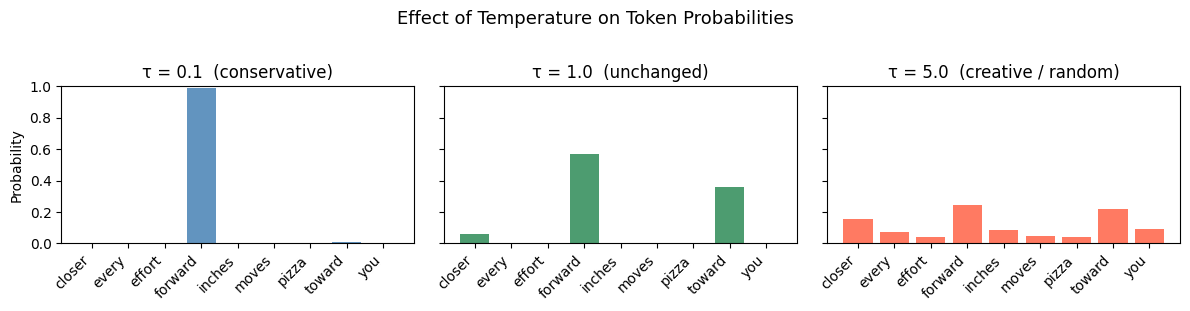

Low τ  → model is very confident, almost always picks 'forward'
High τ → distribution flattens, 'pizza' becomes a realistic option


In [ ]:
# Toy vocabulary to make the effect visible
vocab = {"closer":0, "every":1, "effort":2, "forward":3,
         "inches":4, "moves":5,  "pizza":6,  "toward":7, "you":8}
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

temperatures = [0.1, 1.0, 5.0]
colors = ["steelblue", "seagreen", "tomato"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, T, c in zip(axes, temperatures, colors):
    scaled = torch.softmax(next_token_logits / T, dim=0)
    ax.bar(list(vocab.keys()), scaled.numpy(), color=c, alpha=0.85)
    ax.set_title(f"τ = {T}", fontsize=13)
    ax.set_xticklabels(list(vocab.keys()), rotation=45, ha="right")
    ax.set_ylabel("Probability" if ax == axes[0] else "")
    ax.set_ylim(0, 1)
axes[0].set_title("τ = 0.1  (conservative)", fontsize=12)
axes[1].set_title("τ = 1.0  (unchanged)", fontsize=12)
axes[2].set_title("τ = 5.0  (creative / random)", fontsize=12)
plt.suptitle("Effect of Temperature on Token Probabilities", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("Low τ  → model is very confident, almost always picks 'forward'")
print("High τ → distribution flattens, 'pizza' becomes a realistic option")

### Top-k sampling

Even with high temperature we might sample nonsense tokens with vanishingly small probability. Top-k truncates the distribution to only the k most likely tokens before sampling — combining the creativity of temperature with a guard rail against truly unlikely outputs.

/tmp/ipykernel_54095/2382447690.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(vocab.keys()), rotation=45, ha="right")
/tmp/ipykernel_54095/2382447690.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(vocab.keys()), rotation=45, ha="right")


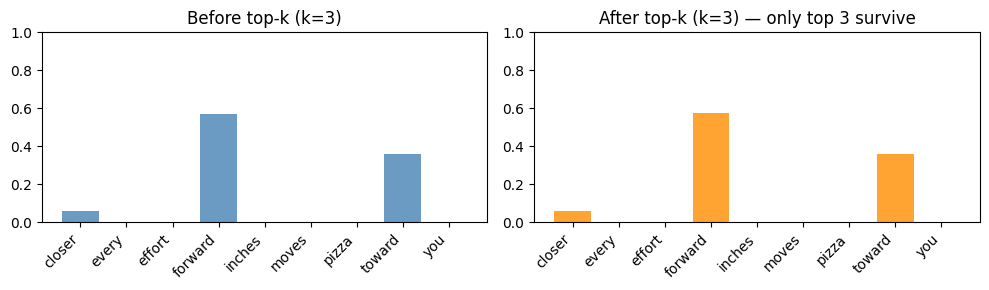

Only 'forward', 'toward', and 'closer' have non-zero probability after top-k.


In [ ]:
# Demonstrate top-k masking
top_k = 3
top_logits, _ = torch.topk(next_token_logits, top_k)
masked_logits = torch.where(
    next_token_logits < top_logits[-1],
    torch.tensor(float("-inf")),
    next_token_logits
)
topk_probs = torch.softmax(masked_logits, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar(list(vocab.keys()), torch.softmax(next_token_logits, dim=0).numpy(),
            color="steelblue", alpha=0.8)
axes[0].set_title("Before top-k (k=3)")
axes[1].bar(list(vocab.keys()), topk_probs.numpy(), color="darkorange", alpha=0.8)
axes[1].set_title("After top-k (k=3) — only top 3 survive")
for ax in axes:
    ax.set_xticklabels(list(vocab.keys()), rotation=45, ha="right")
    ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()
print("Only 'forward', 'toward', and 'closer' have non-zero probability after top-k.")

### The full `generate()` function

We upgrade `generate_text_simple` with both controls. Setting `temperature=0` falls back to greedy (deterministic), giving us one function that handles all cases.

In [ ]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(idx[:, -context_size:])[:, -1, :]

        # ── Top-k filter ──────────────────────────────────────────────────
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            logits = torch.where(
                logits < top_logits[:, -1],
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )

        # ── Temperature + sampling (or greedy) ───────────────────────────
        if temperature > 0.0:
            probs    = torch.softmax(logits / temperature, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # ── Optional early stop at end-of-text token ─────────────────────
        if eos_id is not None and idx_next.item() == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [ ]:
# ── Load the trained model from last session ─────────────────────────────────
# (If you don't have a saved model, train one quickly below)
GPT_CONFIG_TRAIN = {
    "vocab_size": 50257, "context_length": 256,
    "emb_dim": 768, "n_heads": 12, "n_layers": 12,
    "drop_rate": 0.1, "qkv_bias": False
}

# Download "The Verdict" and train a quick model if no checkpoint exists
import os
if not os.path.exists("the-verdict.txt"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/"
        "main/ch02/01_main-chapter-code/the-verdict.txt",
        "the-verdict.txt"
    )

with open("the-verdict.txt", encoding="utf-8") as f:
    text_data = f.read()

# ── Quick re-train if no saved weights ───────────────────────────────────────
if not os.path.exists("gpt_verdict.pth"):
    print("No saved model found — training a quick one (≈5 min on CPU)...")

    class GPTDatasetV1(Dataset):
        def __init__(self, txt, tokenizer, max_length, stride):
            self.input_ids, self.target_ids = [], []
            ids = tokenizer.encode(txt)
            for i in range(0, len(ids) - max_length, stride):
                self.input_ids.append(torch.tensor(ids[i:i+max_length]))
                self.target_ids.append(torch.tensor(ids[i+1:i+max_length+1]))
        def __len__(self): return len(self.input_ids)
        def __getitem__(self, idx): return self.input_ids[idx], self.target_ids[idx]

    ctx = GPT_CONFIG_TRAIN["context_length"]
    split = int(0.9 * len(text_data))
    train_loader = DataLoader(GPTDatasetV1(text_data[:split], tokenizer, ctx, ctx),
                              batch_size=2, shuffle=True, drop_last=True)
    val_loader   = DataLoader(GPTDatasetV1(text_data[split:], tokenizer, ctx, ctx),
                              batch_size=2, shuffle=False, drop_last=False)

    def calc_loss_batch(xb, yb, model, device):
        xb, yb = xb.to(device), yb.to(device)
        return torch.nn.functional.cross_entropy(model(xb).flatten(0,1), yb.flatten())

    torch.manual_seed(123)
    model = GPTModel(GPT_CONFIG_TRAIN).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)
    for epoch in range(10):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(); calc_loss_batch(xb, yb, model, device).backward(); opt.step()
        print(f"Epoch {epoch+1}/10 done")
    torch.save(model.state_dict(), "gpt_verdict.pth")
    print("Saved to gpt_verdict.pth")
else:
    model = GPTModel(GPT_CONFIG_TRAIN)
    model.load_state_dict(torch.load("gpt_verdict.pth", map_location=device))
    model.to(device)
    print("Loaded saved model ✓")

model.eval()

No saved model found — training a quick one (≈5 min on CPU)...
Epoch 1/10 done
Epoch 2/10 done
Epoch 3/10 done
Epoch 4/10 done
Epoch 5/10 done
Epoch 6/10 done
Epoch 7/10 done
Epoch 8/10 done
Epoch 9/10 done
Epoch 10/10 done
Saved to gpt_verdict.pth


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out

In [ ]:
# ── Compare greedy vs temperature+top-k on the same prompt ──────────────────
prompt = "The Supreme Court held"

torch.manual_seed(42)
greedy = generate(model, text_to_token_ids(prompt, tokenizer).to(device),
                  max_new_tokens=30, context_size=GPT_CONFIG_TRAIN["context_length"])

torch.manual_seed(42)
creative = generate(model, text_to_token_ids(prompt, tokenizer).to(device),
                    max_new_tokens=30, context_size=GPT_CONFIG_TRAIN["context_length"],
                    temperature=1.2, top_k=20)

print("Greedy (τ=0):          ", token_ids_to_text(greedy, tokenizer))
print("Creative (τ=1.2, k=20):", token_ids_to_text(creative, tokenizer))

Greedy (τ=0):           The Supreme Court held sunburnt cheeks furrowed by a smile that lifted the tips of a self-confident moustache, I felt to see a smile
Creative (τ=1.2, k=20): The Supreme Court held?"

"-t Mrs. But Mrs. When had sent him--so it all--had not to on groping and Mrs. G


---
## Part 2 — Saving & Loading Model Weights

Training is expensive — always save checkpoints. PyTorch's `state_dict` stores only the learnable parameters (not the architecture), keeping files compact and portable.

---
## Part 3 — Classification Fine-tuning (Spam Detection)

### The idea

We take a pretrained GPT-2 and repurpose it as a spam classifier. The key architectural change is minimal: **swap the output head**.

```
Before:  768-dim hidden → Linear(768, 50257)  → next-token logits
After:   768-dim hidden → Linear(768, 2)      → [not-spam score, spam score]
```

We also **freeze** all layers except the last transformer block and the new head — this keeps the linguistic knowledge intact while adapting only the task-specific layers.

Why use the **last token's** output? Because of causal masking, only the last token has attended to the entire input sequence. It contains the most context-aware representation.

### Architecture surgery

In [ ]:
# ── GPT-2 Small config (no dropout for fine-tuning) ─────────────────────────
BASE_CONFIG = {
    "vocab_size": 50257, "context_length": 1024,
    "emb_dim": 768, "n_heads": 12, "n_layers": 12,
    "drop_rate": 0.0,     # Dropout off during fine-tuning
    "qkv_bias": True      # OpenAI GPT-2 uses QKV bias
}

# ── Download pretrained OpenAI GPT-2 weights ─────────────────────────────────
# This downloads gpt_download.py from Raschka's repo
import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/"
    "main/ch05/01_main-chapter-code/gpt_download.py",
    "gpt_download.py"
)
from gpt_download import download_and_load_gpt2

def load_weights_into_gpt(gpt, params):
    """Copy OpenAI TF weights into our PyTorch GPTModel."""
    gpt.pos_emb.weight = nn.Parameter(torch.tensor(params["wpe"]))
    gpt.tok_emb.weight = nn.Parameter(torch.tensor(params["wte"]))
    for b, block in enumerate(gpt.trf_blocks):
        q,k,v = np.split(params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1)
        block.att.W_query.weight = nn.Parameter(torch.tensor(q).T)
        block.att.W_key.weight   = nn.Parameter(torch.tensor(k).T)
        block.att.W_value.weight = nn.Parameter(torch.tensor(v).T)
        q_b,k_b,v_b = np.split(params["blocks"][b]["attn"]["c_attn"]["b"], 3)
        block.att.W_query.bias = nn.Parameter(torch.tensor(q_b))
        block.att.W_key.bias   = nn.Parameter(torch.tensor(k_b))
        block.att.W_value.bias = nn.Parameter(torch.tensor(v_b))
        block.att.out_proj.weight = nn.Parameter(torch.tensor(params["blocks"][b]["attn"]["c_proj"]["w"]).T)
        block.att.out_proj.bias   = nn.Parameter(torch.tensor(params["blocks"][b]["attn"]["c_proj"]["b"]))
        block.ff.layers[0].weight = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_fc"]["w"]).T)
        block.ff.layers[0].bias   = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_fc"]["b"]))
        block.ff.layers[2].weight = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_proj"]["w"]).T)
        block.ff.layers[2].bias   = nn.Parameter(torch.tensor(params["blocks"][b]["mlp"]["c_proj"]["b"]))
        block.norm1.scale = nn.Parameter(torch.tensor(params["blocks"][b]["ln_1"]["g"]))
        block.norm1.shift = nn.Parameter(torch.tensor(params["blocks"][b]["ln_1"]["b"]))
        block.norm2.scale = nn.Parameter(torch.tensor(params["blocks"][b]["ln_2"]["g"]))
        block.norm2.shift = nn.Parameter(torch.tensor(params["blocks"][b]["ln_2"]["b"]))
    gpt.final_norm.scale = nn.Parameter(torch.tensor(params["g"]))
    gpt.final_norm.shift = nn.Parameter(torch.tensor(params["b"]))
    gpt.out_head.weight  = nn.Parameter(torch.tensor(params["wte"]))

import numpy as np
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
clf_model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(clf_model, params)
print("Pretrained GPT-2 (124M) loaded ✓")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 271kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.37MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 216kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:35<00:00, 14.2MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 10.3MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.86MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.56MiB/s]


Pretrained GPT-2 (124M) loaded ✓


In [ ]:
# ── Freeze all layers ────────────────────────────────────────────────────────
for param in clf_model.parameters():
    param.requires_grad = False

# ── Replace the output head with a 2-class classifier ────────────────────────
torch.manual_seed(123)
clf_model.out_head = nn.Linear(BASE_CONFIG["emb_dim"], 2)  # requires_grad=True by default

# ── Unfreeze only the last transformer block + final LayerNorm ───────────────
for param in clf_model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in clf_model.final_norm.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in clf_model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print("We only train ~7M out of 124M parameters — 10x less compute than full fine-tuning.")

Trainable parameters: 7,090,946 / 124,441,346 (5.7%)
We only train ~7M out of 124M parameters — 10x less compute than full fine-tuning.


### Dataset: SMS Spam Collection

A classic benchmark: 5,572 text messages labelled "spam" or "ham" (not spam).
We balance it (747 each), split 70/10/20, and pad to the longest sequence length.

In [ ]:
import zipfile, os
from pathlib import Path

# ── Download ──────────────────────────────────────────────────────────────────
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
if not Path("sms_spam_collection/SMSSpamCollection.tsv").exists():
    urllib.request.urlretrieve(url, "sms_spam.zip")
    with zipfile.ZipFile("sms_spam.zip", "r") as z: z.extractall("sms_spam_collection")
    os.rename("sms_spam_collection/SMSSpamCollection",
              "sms_spam_collection/SMSSpamCollection.tsv")

df = pd.read_csv("sms_spam_collection/SMSSpamCollection.tsv",
                 sep="\t", header=None, names=["Label","Text"])
print(df["Label"].value_counts())

# ── Balance ───────────────────────────────────────────────────────────────────
n_spam = df[df["Label"]=="spam"].shape[0]
balanced_df = pd.concat([
    df[df["Label"]=="ham"].sample(n_spam, random_state=123),
    df[df["Label"]=="spam"]
])
balanced_df["Label"] = balanced_df["Label"].map({"ham":0, "spam":1})

# ── Split 70/10/20 ────────────────────────────────────────────────────────────
df_s = balanced_df.sample(frac=1, random_state=123).reset_index(drop=True)
n = len(df_s)
train_df = df_s[:int(0.7*n)]; val_df = df_s[int(0.7*n):int(0.8*n)]; test_df = df_s[int(0.8*n):]
train_df.to_csv("train.csv", index=False); val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Label
ham     4825
spam     747
Name: count, dtype: int64
Train: 1045 | Val: 150 | Test: 299


In [ ]:
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [tokenizer.encode(t) for t in self.data["Text"]]
        self.max_length = max_length or max(len(e) for e in self.encoded_texts)
        # Truncate then pad
        self.encoded_texts = [
            (e[:self.max_length] + [pad_token_id] * (self.max_length - len(e[:self.max_length])))
            for e in self.encoded_texts
        ]
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        return (torch.tensor(self.encoded_texts[idx], dtype=torch.long),
                torch.tensor(self.data.iloc[idx]["Label"], dtype=torch.long))

train_ds = SpamDataset("train.csv", tokenizer)
val_ds   = SpamDataset("val.csv",   tokenizer, max_length=train_ds.max_length)
test_ds  = SpamDataset("test.csv",  tokenizer, max_length=train_ds.max_length)

train_loader_clf = DataLoader(train_ds, batch_size=8, shuffle=True,  drop_last=True)
val_loader_clf   = DataLoader(val_ds,   batch_size=8, shuffle=False, drop_last=False)
test_loader_clf  = DataLoader(test_ds,  batch_size=8, shuffle=False, drop_last=False)

print(f"Max sequence length: {train_ds.max_length} tokens")
print(f"Train batches: {len(train_loader_clf)} | Val: {len(val_loader_clf)} | Test: {len(test_loader_clf)}")

Max sequence length: 120 tokens
Train batches: 130 | Val: 19 | Test: 38


### Training the classifier

The loss and training loop are almost identical to pretraining — the key difference is that we **only use the last token's output** (`logits[:, -1, :]`) for the 2-class prediction, and we track **accuracy** instead of generating sample text.

In [ ]:
def calc_loss_batch_clf(xb, yb, model, device):
    xb, yb = xb.to(device), yb.to(device)
    logits = model(xb)[:, -1, :]   # Last token only → (batch, 2)
    return torch.nn.functional.cross_entropy(logits, yb)

def calc_accuracy_loader(loader, model, device, num_batches=None):
    model.eval()
    correct, total = 0, 0
    for i, (xb, yb) in enumerate(loader):
        if num_batches and i >= num_batches: break
        with torch.no_grad():
            logits = model(xb.to(device))[:, -1, :]
        correct += (logits.argmax(dim=-1) == yb.to(device)).sum().item()
        total   += yb.shape[0]
    return correct / total

def train_classifier(model, train_loader, val_loader, optimizer, device,
                     num_epochs, eval_freq):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    step = 0
    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            calc_loss_batch_clf(xb, yb, model, device).backward()
            optimizer.step(); step += 1
            if step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    tl = sum(calc_loss_batch_clf(x,y,model,device).item()
                             for x,y in list(train_loader)[:5]) / 5
                    vl = sum(calc_loss_batch_clf(x,y,model,device).item()
                             for x,y in list(val_loader)[:5]) / 5
                train_losses.append(tl); val_losses.append(vl)
                print(f"Ep {epoch+1} Step {step:04d}: train={tl:.3f}  val={vl:.3f}")
                model.train()
        ta = calc_accuracy_loader(train_loader, model, device, num_batches=10)
        va = calc_accuracy_loader(val_loader,   model, device)
        train_accs.append(ta); val_accs.append(va)
        print(f"  → Train acc: {ta*100:.1f}%  Val acc: {va*100:.1f}%")
    return train_losses, val_losses, train_accs, val_accs

In [ ]:
clf_model.to(device)
optimizer_clf = torch.optim.AdamW(clf_model.parameters(), lr=5e-5, weight_decay=0.1)

train_losses_clf, val_losses_clf, train_accs, val_accs = train_classifier(
    clf_model, train_loader_clf, val_loader_clf, optimizer_clf, device,
    num_epochs=5, eval_freq=50
)

Ep 1 Step 0050: train=0.642  val=0.638
Ep 1 Step 0100: train=0.538  val=0.560
  → Train acc: 92.5%  Val acc: 88.0%
Ep 2 Step 0150: train=0.618  val=0.461
Ep 2 Step 0200: train=0.420  val=0.388
Ep 2 Step 0250: train=0.430  val=0.348
  → Train acc: 83.8%  Val acc: 88.0%
Ep 3 Step 0300: train=0.308  val=0.308
Ep 3 Step 0350: train=0.285  val=0.306
  → Train acc: 88.8%  Val acc: 88.7%
Ep 4 Step 0400: train=0.506  val=0.341
Ep 4 Step 0450: train=0.276  val=0.263
Ep 4 Step 0500: train=0.069  val=0.178
  → Train acc: 91.2%  Val acc: 92.7%
Ep 5 Step 0550: train=0.130  val=0.157
Ep 5 Step 0600: train=0.167  val=0.139
Ep 5 Step 0650: train=0.080  val=0.116
  → Train acc: 92.5%  Val acc: 96.0%


In [ ]:
# ── Final accuracy across full datasets ───────────────────────────────────────
print(f"Train accuracy: {calc_accuracy_loader(train_loader_clf, clf_model, device)*100:.2f}%")
print(f"Val   accuracy: {calc_accuracy_loader(val_loader_clf,   clf_model, device)*100:.2f}%")
print(f"Test  accuracy: {calc_accuracy_loader(test_loader_clf,  clf_model, device)*100:.2f}%")

# ── Try it on new messages ────────────────────────────────────────────────────
def classify(text, model, tokenizer, device, max_length, pad_token_id=50256):
    model.eval()
    ids = tokenizer.encode(text)[:max_length]
    ids += [pad_token_id] * (max_length - len(ids))
    with torch.no_grad():
        logits = model(torch.tensor(ids).unsqueeze(0).to(device))[:, -1, :]
    return "SPAM" if logits.argmax().item() == 1 else "not spam"

ml = train_ds.max_length
print("\n--- Live classification ---")
print(classify("You are a winner! Claim your $1000 prize now!", clf_model, tokenizer, device, ml))
print(classify("Hey, are we still meeting for coffee tomorrow?", clf_model, tokenizer, device, ml))
print(classify("FREE entry to win £250. Text WIN to 87121.", clf_model, tokenizer, device, ml))

Train accuracy: 95.96%
Val   accuracy: 96.00%
Test  accuracy: 95.65%

--- Live classification ---
not spam
not spam
SPAM


---
## Part 4 — Instruction Fine-tuning

### Classification vs Instruction fine-tuning

| | Classification | Instruction |
|---|---|---|
| **Output** | Fixed class label (spam/not spam) | Free-form text |
| **Architecture change** | New 2-class output head | None — same vocab head |
| **Training signal** | Cross-entropy on 1 label | Cross-entropy on every response token |
| **Data** | (text, label) pairs | (instruction, response) pairs |
| **Use case** | Narrow task | General-purpose assistant |

The idea: pretrained GPT knows language; we teach it **when and how to respond** by training it on thousands of instruction–response examples.

### The Alpaca prompt format

Every training example is wrapped in a fixed template so the model learns *where the instruction ends and the response begins*:

```
Below is an instruction that describes a task. Write a response that
appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Input:          ← optional, omitted if empty
The chef cooks the meal every day.

### Response:
The meal is cooked every day by the chef.
```

The `### Response:` marker is the signal — the model learns to generate what comes after it.

In [ ]:
# ── Download the instruction dataset ─────────────────────────────────────────
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
       "/main/ch07/01_main-chapter-code/instruction-data.json")
if not os.path.exists("instruction-data.json"):
    urllib.request.urlretrieve(url, "instruction-data.json")

with open("instruction-data.json") as f:
    data = json.load(f)

print(f"Total examples: {len(data)}")
print("\nExample entry:")
print(json.dumps(data[50], indent=2))

Total examples: 1100

Example entry:
{
  "instruction": "Identify the correct spelling of the following word.",
  "input": "Ocassion",
  "output": "The correct spelling is 'Occasion.'"
}


In [ ]:
def format_input(entry):
    """Wrap an instruction-data entry in the Alpaca prompt template."""
    instruction_text = (
        "Below is an instruction that describes a task. "
        "Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

# Show what a formatted example looks like (input + expected response)
print(format_input(data[50]))
print(f"\n\n### Response:\n{data[50]['output']}")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion


### Response:
The correct spelling is 'Occasion.'


In [ ]:
# ── Train / val / test split: 85% / 5% / 10% ────────────────────────────────
train_portion = int(len(data) * 0.85)
test_portion  = int(len(data) * 0.10)
train_data = data[:train_portion]
test_data  = data[train_portion:train_portion + test_portion]
val_data   = data[train_portion + test_portion:]

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 935 | Val: 55 | Test: 110


### Building training batches — the hard part

For classification we had neat (text, label) pairs. Here **the target is the response itself**, formatted as a continuation of the prompt. The data pipeline has five steps:

1. Format with the Alpaca template
2. Tokenize the full `prompt + response` string
3. Pad to the longest sequence in each batch (not the whole dataset)
4. Create targets = inputs shifted one position right (next-token prediction, same as pretraining)
5. Replace all **padding tokens** in the targets with `-100`

Step 5 is the clever trick: PyTorch's `cross_entropy` ignores targets labelled `-100` by default (`ignore_index=-100`). This means padding positions contribute **zero loss** — the model only learns from real response tokens.

In [ ]:
# ── Why -100 matters: a self-contained demo ──────────────────────────────────
logits_demo = torch.tensor([
    [-1.0,  1.0],   # prediction for position 1
    [-0.5,  1.5],   # prediction for position 2
    [-0.5,  1.5],   # prediction for position 3 (padding)
])
targets_real    = torch.tensor([0, 1, 1])        # all positions count
targets_masked  = torch.tensor([0, 1, -100])     # position 3 ignored

loss_real   = torch.nn.functional.cross_entropy(logits_demo, targets_real)
loss_masked = torch.nn.functional.cross_entropy(logits_demo, targets_masked)

print(f"Loss with 3 targets (including padding): {loss_real:.4f}")
print(f"Loss with 2 targets (-100 masks padding): {loss_masked:.4f}")
print(f"\nThe two losses differ because the padding position contributes 0")
print("when masked with -100, exactly as if it didn't exist.")

Loss with 3 targets (including padding): 0.7936
Loss with 2 targets (-100 masks padding): 1.1269

The two losses differ because the padding position contributes 0
when masked with -100, exactly as if it didn't exist.


In [ ]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.encoded_texts = []
        for entry in data:
            full_text = format_input(entry) + f"\n\n### Response:\n{entry['output']}"
            self.encoded_texts.append(tokenizer.encode(full_text))
    def __len__(self): return len(self.encoded_texts)
    def __getitem__(self, idx): return self.encoded_texts[idx]

This custom collate function pads the training examples in each batch to the same length while allowing different batches to have different lengths.

In [ ]:
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100,
                      allowed_max_length=None, device="cpu"):
    # 1. Find longest sequence in this batch and pad all to that length
    max_len = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        padded = item + [pad_token_id] * (max_len - len(item))   # pad to max
        inputs  = torch.tensor(padded[:-1])      # drop last → inputs
        targets = torch.tensor(padded[1:])       # shift right → targets

        # 2. Replace all but the FIRST end-of-text token in targets with -100
        #    (keep one so the model learns to emit EOS; mask the rest)
        pad_positions = (targets == pad_token_id).nonzero().squeeze(-1)
        if pad_positions.numel() > 1:
            targets[pad_positions[1:]] = ignore_index

        # 3. Optional truncation to model's context window
        if allowed_max_length:
            inputs  = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs); targets_lst.append(targets)

    return (torch.stack(inputs_lst).to(device),
            torch.stack(targets_lst).to(device))


# ── Verify on a toy batch ─────────────────────────────────────────────────────
toy_batch = [[0, 1, 2, 3, 4], [5, 6], [7, 8, 9]]
inp, tgt  = custom_collate_fn(toy_batch)
print("Inputs: \n", inp)
print("Targets (note -100 masking the extra padding):\n", tgt)


Inputs: 
 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets (note -100 masking the extra padding):
 tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


cross_entropy(..., ignore_index=-100)

In [ ]:
from functools import partial

customized_collate = partial(custom_collate_fn, device=device, allowed_max_length=1024)

train_ins_ds = InstructionDataset(train_data, tokenizer)
val_ins_ds   = InstructionDataset(val_data,   tokenizer)
test_ins_ds  = InstructionDataset(test_data,  tokenizer)

train_ins_loader = DataLoader(train_ins_ds, batch_size=8, shuffle=True,
                               drop_last=True,  collate_fn=customized_collate)
val_ins_loader   = DataLoader(val_ins_ds,   batch_size=8, shuffle=False,
                               drop_last=False, collate_fn=customized_collate)
test_ins_loader  = DataLoader(test_ins_ds,  batch_size=8, shuffle=False,
                               drop_last=False, collate_fn=customized_collate)

# Show that batches have variable length (dynamic padding per batch)
print("Batch shapes (inputs, targets):")
for i, (xb, yb) in enumerate(train_ins_loader):
    print(f"  Batch {i+1}: {xb.shape}")
    if i == 3: print("  ..."); break

Batch shapes (inputs, targets):
  Batch 1: torch.Size([8, 64])
  Batch 2: torch.Size([8, 63])
  Batch 3: torch.Size([8, 70])
  Batch 4: torch.Size([8, 61])
  ...


### Load GPT-2 and see what it can do *before* fine-tuning

We use GPT-2 **medium (355M)** — the small model (124M) lacks the capacity to produce good instruction-following responses. If memory is tight, swap to `"gpt2-small (124M)"`.

In [ ]:
INS_CONFIG = {
    "vocab_size": 50257, "context_length": 1024,
    "emb_dim": 1024, "n_heads": 16, "n_layers": 24,   # Medium
    "drop_rate": 0.0, "qkv_bias": True
}
# ── For CPU-only machines, use small instead ──────────────────────────────────
# INS_CONFIG = {**BASE_CONFIG}   # uncomment to use 124M small

settings_m, params_m = download_and_load_gpt2(model_size="355M", models_dir="gpt2")
ins_model = GPTModel(INS_CONFIG)
load_weights_into_gpt(ins_model, params_m)
ins_model.eval()
print("GPT-2 Medium (355M) loaded ✓")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 159kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.56MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 92.9kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [02:02<00:00, 11.5MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 20.1MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 2.61MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.58MiB/s]


GPT-2 Medium (355M) loaded ✓


In [ ]:
# ── Baseline: what does the pretrained model answer before fine-tuning? ───────
sample = val_data[0]
prompt = format_input(sample)
print(prompt)
print("\n--- Expected response ---")
print(sample["output"])

token_ids = generate(
    ins_model,
    text_to_token_ids(prompt, tokenizer),
    max_new_tokens=50,
    context_size=INS_CONFIG["context_length"],
    temperature=0.0,
    eos_id=50256
)
response = token_ids_to_text(token_ids, tokenizer)[len(prompt):].strip()
print("\n--- Pretrained model response (before fine-tuning) ---")
print(response)
print("\nObservation: the model continues the text instead of answering the instruction.")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

--- Expected response ---
The meal is cooked by the chef every day.

--- Pretrained model response (before fine-tuning) ---
### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the

Observation: the model continues the text instead of answering the instruction.


### Fine-tune!

We reuse exactly the same `train_model_simple` loop from pretraining — nothing changes except the data. The model is trained on `(instruction + response)` sequences, predicting one token at a time. The `-100` masking ensures it only gets credit (and gradient) for the response tokens, not for re-predicting the instruction.

In [ ]:
def calc_loss_loader_ins(loader, model, device, num_batches=None):
    total, n = 0., min(num_batches or len(loader), len(loader))
    for i, (xb, yb) in enumerate(loader):
        if i >= n: break
        xb, yb = xb.to(device), yb.to(device)
        total += torch.nn.functional.cross_entropy(
            model(xb).flatten(0,1), yb.flatten(), ignore_index=-100
        ).item()
    return total / n

ins_model.to(device)
with torch.no_grad():
    tl = calc_loss_loader_ins(train_ins_loader, ins_model, device, num_batches=5)
    vl = calc_loss_loader_ins(val_ins_loader,   ins_model, device, num_batches=5)
print(f"Initial loss — Train: {tl:.3f}  Val: {vl:.3f}")

Initial loss — Train: 3.789  Val: 3.762


In [ ]:
def train_instruction_model(model, train_loader, val_loader, optimizer,
                           device, num_epochs, eval_freq, eval_iter,
                           val_sample, tokenizer):
    train_losses, val_losses, tokens_seen = [], [], []
    seen, step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            xb, yb = xb.to(device), yb.to(device)
            loss = torch.nn.functional.cross_entropy(
                model(xb).flatten(0,1), yb.flatten(), ignore_index=-100
            )
            loss.backward(); optimizer.step()
            seen += xb.numel(); step += 1

            if step % eval_freq == 0:
                tl = calc_loss_loader_ins(train_loader, model, device, eval_iter)
                vl = calc_loss_loader_ins(val_loader,   model, device, eval_iter)
                train_losses.append(tl); val_losses.append(vl); tokens_seen.append(seen)
                print(f"Ep {epoch+1} Step {step:04d}: train={tl:.3f}  val={vl:.3f}")

        # ── Print a sample response after each epoch ──────────────────────
        model.eval()
        prompt = format_input(val_sample)
        token_ids = generate(model, text_to_token_ids(prompt, tokenizer).to(device),
                             max_new_tokens=80, context_size=INS_CONFIG["context_length"],
                             temperature=0.0, eos_id=50256)
        resp = token_ids_to_text(token_ids, tokenizer)[len(prompt):]
        resp = resp.replace("### Response:", "").strip()
        print(f"  Sample response: {resp[:120]}...")
        model.train()

    return train_losses, val_losses, tokens_seen


torch.manual_seed(123)
optimizer_ins = torch.optim.AdamW(ins_model.parameters(), lr=5e-5, weight_decay=0.1)

t0 = time.time()
train_losses_ins, val_losses_ins, tokens_seen_ins = train_instruction_model(
    ins_model, train_ins_loader, val_ins_loader, optimizer_ins, device,
    num_epochs=2, eval_freq=5, eval_iter=5,
    val_sample=val_data[0], tokenizer=tokenizer
)
print(f"\nTraining completed in {(time.time()-t0)/60:.1f} min")

Ep 1 Step 0000: train=2.637  val=2.626
Ep 1 Step 0005: train=1.174  val=1.103
Ep 1 Step 0010: train=0.872  val=0.944
Ep 1 Step 0015: train=0.857  val=0.906
Ep 1 Step 0020: train=0.776  val=0.881
Ep 1 Step 0025: train=0.754  val=0.859
Ep 1 Step 0030: train=0.799  val=0.836
Ep 1 Step 0035: train=0.714  val=0.808
Ep 1 Step 0040: train=0.672  val=0.806
Ep 1 Step 0045: train=0.633  val=0.789
Ep 1 Step 0050: train=0.663  val=0.783
Ep 1 Step 0055: train=0.760  val=0.763
Ep 1 Step 0060: train=0.719  val=0.743
Ep 1 Step 0065: train=0.653  val=0.735
Ep 1 Step 0070: train=0.533  val=0.729
Ep 1 Step 0075: train=0.568  val=0.729
Ep 1 Step 0080: train=0.604  val=0.725
Ep 1 Step 0085: train=0.509  val=0.710
Ep 1 Step 0090: train=0.563  val=0.691
Ep 1 Step 0095: train=0.502  val=0.681
Ep 1 Step 0100: train=0.504  val=0.677
Ep 1 Step 0105: train=0.565  val=0.670
Ep 1 Step 0110: train=0.554  val=0.666
Ep 1 Step 0115: train=0.508  val=0.663
  Sample response: The meal is prepared every day by the chef...

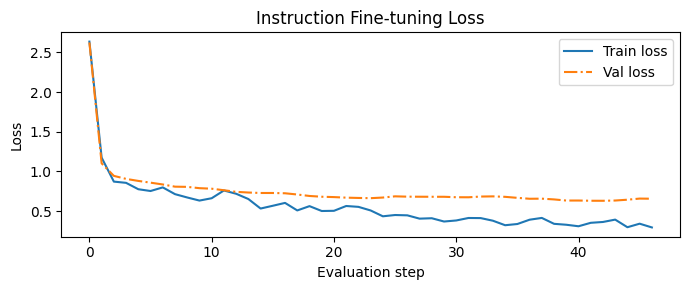

In [ ]:
# ── Loss curves ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_losses_ins, label="Train loss")
ax.plot(val_losses_ins,   label="Val loss", linestyle="-.")
ax.set_xlabel("Evaluation step"); ax.set_ylabel("Loss")
ax.set_title("Instruction Fine-tuning Loss")
ax.legend(); plt.tight_layout(); plt.show()

### Before vs. After — qualitative comparison

Let's compare the model's responses on several test examples before and after fine-tuning.

In [ ]:
ins_model.eval()
for entry in test_data[:4]:
    prompt = format_input(entry)
    token_ids = generate(
        ins_model,
        text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=100,
        context_size=INS_CONFIG["context_length"],
        temperature=0.0,
        eos_id=50256
    )
    response = (token_ids_to_text(token_ids, tokenizer)[len(prompt):]
                .replace("### Response:", "").strip())
    print(f"Instruction: {entry['instruction']}")
    if entry["input"]: print(f"Input:       {entry['input']}")
    print(f"Expected:    {entry['output']}")
    print(f"Model:       {response[:200]}")
    print("-" * 60)

Instruction: Rewrite the sentence using a simile.
Input:       The car is very fast.
Expected:    The car is as fast as lightning.
Model:       The car is as fast as a bullet.
------------------------------------------------------------
Instruction: What type of cloud is typically associated with thunderstorms?
Expected:    The type of cloud typically associated with thunderstorms is cumulonimbus.
Model:       The type of cloud associated with thunderstorms is a cumulus cloud.
------------------------------------------------------------
Instruction: Name the author of 'Pride and Prejudice'.
Expected:    Jane Austen.
Model:       The author of 'Pride and Prejudice' is Jane Austen.
------------------------------------------------------------
Instruction: What is the periodic symbol for chlorine?
Expected:    The periodic symbol for chlorine is Cl.
Model:       The periodic symbol for chlorine is C.
------------------------------------------------------------


In [ ]:
# ── Save the fine-tuned model ─────────────────────────────────────────────────
import re
file_name = "gpt2-medium355M-instruction-finetuned.pth"
torch.save(ins_model.state_dict(), file_name)
print(f"Saved → {file_name}")
print("Load later with:")
print("  m = GPTModel(INS_CONFIG)")
print(f"  m.load_state_dict(torch.load('{file_name}', map_location=device))")

KeyboardInterrupt: 